In [1]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
from ibicus.debias import QuantileMapping

In [2]:
from srm import downscaling_utils

# 0. Get data

In [3]:
RUN_PARAMETERS = {
    "OBS": "ERA5",
    "GCM": "CESM2-WACCM",
    "TRAIN_PERIOD_START": 1978 + 5,
    "TRAIN_PERIOD_END": 2014,
    "PREDICT_PERIOD_START": 2015,
    "PREDICT_PERIOD_END": 2100,
    "VAR": "tas",
}

In [4]:
# Get model data
ssp245 = downscaling_utils.get_experiment(
    gcm=RUN_PARAMETERS["GCM"], scenario="SSP245", var=RUN_PARAMETERS["VAR"]
)

# Select a single ensemble member
ssp245 = ssp245.isel(ensemble_member=0)

model_historical = downscaling_utils.get_experiment(
    gcm=RUN_PARAMETERS["GCM"], scenario="Historical", var=RUN_PARAMETERS["VAR"]
)

In [5]:
era5 = downscaling_utils.get_obs(var=RUN_PARAMETERS["VAR"])

In [6]:
df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'South Africa'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds as a couple of degrees around South Africa
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

In [7]:
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_x, cape_town_y = (
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),
)

/tmp/ipykernel_5171/1595652233.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
/tmp/ipykernel_5171/1595652233.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),


### Subset data to demo region (South Africa)

In [8]:
era5_SA = downscaling_utils.subset_space(
    era5, coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
)

model_historical_SA = downscaling_utils.subset_space(
    model_historical, coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
)

ssp245_SA = downscaling_utils.subset_space(
    ssp245, coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
)

In [9]:
dict_all = {
    "ssp245": ssp245_SA,
    "model_hist": model_historical_SA,
    "era5": era5_SA,
}

# 1. Preprocess data

### Calculate coarse version of high-res observational dataset
(this is an inaccurate linear interpolation -- need to change to area averaging)

In [10]:
dict_all["era5_coarse"] = downscaling_utils.interpolate_to_coarse_grid(
    da_fine_to_coarsen=dict_all["era5"], da_coarse_grid=dict_all["ssp245"]
)

### Subset to years for training and predicting

In [11]:
for key, ds in dict_all.items():
    if "era" in key:
        time_period = "train"
    if "ssp245" in key:
        time_period = "predict"
    if "model_hist" in key:
        time_period = "train"

    dict_all[key] = downscaling_utils.subset_time(
        da=ds, run_parameters=RUN_PARAMETERS, time_period=time_period
    )

# 2. Bias correct with quantile mapping

In [12]:
debiaser = QuantileMapping.from_variable(
    variable="tas", mapping_type="nonparametric", detrending="additive"
)

In [ ]:
obs = dict_all["era5_coarse"].load().values
cm_hist = dict_all["model_hist"].load().values
cm_future = cm_hist

tas_cm_hist_debiased = debiaser.apply(
    obs=obs,
    cm_hist=cm_hist,
    cm_future=cm_future,
    time_obs=dict_all["era5_coarse"]["time"].values,
    time_cm_hist=dict_all["model_hist"]["time"].values,
)

cm_future = dict_all["ssp245"].load().values
ssp245_fut_debiased = debiaser.apply(
    obs=obs,
    cm_hist=cm_hist,
    cm_future=cm_future,
    time_obs=dict_all["era5_coarse"]["time"].values,
    time_cm_hist=dict_all["model_hist"]["time"].values,
    time_cm_future=dict_all["ssp245"]["time"].values,
)

100%|██████████| 620/620 [00:02<00:00, 287.95it/s]


In [14]:
################## Save debiased data to dictionary
dict_all["model_hist_debiased"] = xr.DataArray(
    data=tas_cm_hist_debiased,
    coords={
        "lat": dict_all["model_hist"]["lat"],
        "lon": dict_all["model_hist"]["lon"],
        "time": dict_all["model_hist"]["time"],
    },
    dims=["time", "lat", "lon"],
)

dict_all["ssp245_debiased"] = xr.DataArray(
    data=ssp245_fut_debiased,
    coords={
        "lat": dict_all["ssp245"]["lat"],
        "lon": dict_all["ssp245"]["lon"],
        "time": dict_all["ssp245"]["time"],
    },
    dims=["time", "lat", "lon"],
)

# 3. Downscale

In [ ]:
error_map = downscaling_utils.calculate_error_map(
    obs_coarse=dict_all["era5_coarse"], obs_fine=dict_all["era5"]
)

In [ ]:
dict_all["model_hist_debiased_downscaled"] = downscaling_utils.downscale_from_coarse(
    dict_all["model_hist_debiased"], error_map=error_map, fine_grid=dict_all["era5"]
)

dict_all["ssp245_debiased_downscaled"] = downscaling_utils.downscale_from_coarse(
    dict_all["ssp245_debiased"], error_map=error_map, fine_grid=dict_all["era5"]
)

# Look at results

In [17]:
dict_all_CT = {}
for key, ds in dict_all.items():
    ds_CT = ds.sel(lat=cape_town_y, lon=cape_town_x, method="nearest")
    dict_all_CT[key] = ds_CT

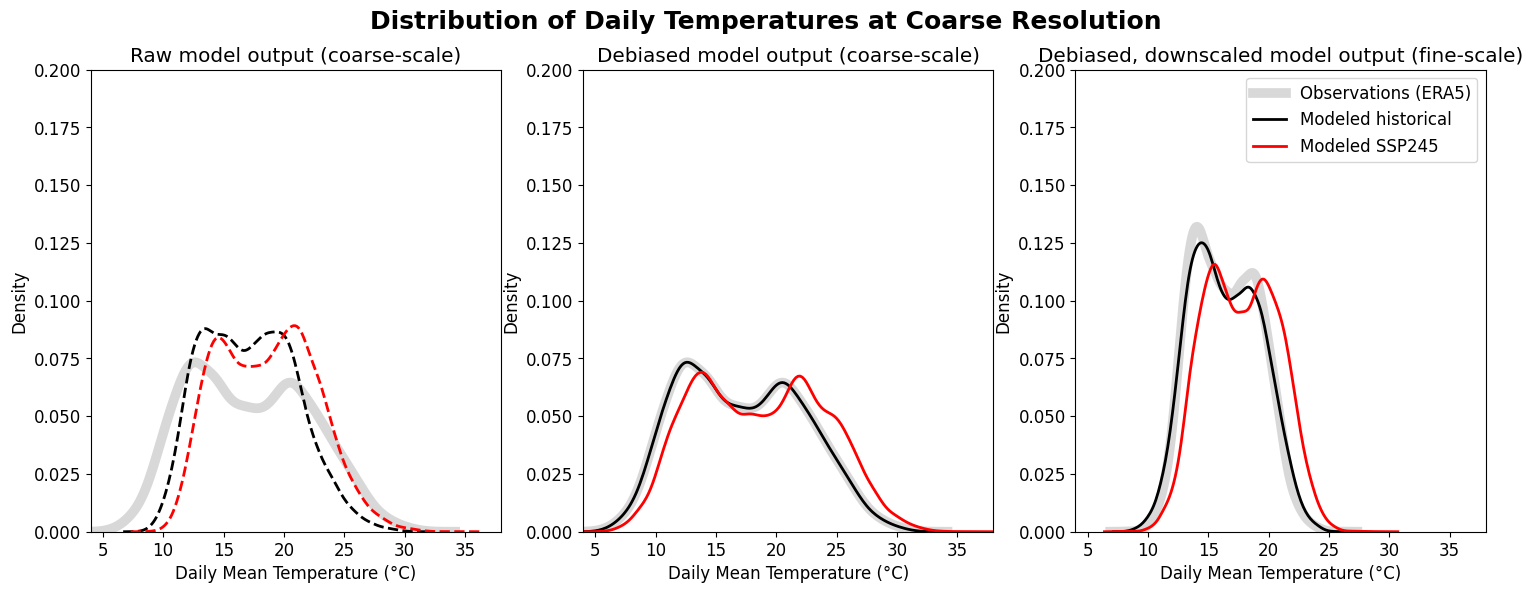

In [ ]:
colors = ["black", "red"]
labels = ["Modeled historical", "Modeled SSP245"]
dataset_keys = ["model_hist", "ssp245"]

plt.rcParams["font.size"] = 12


def format_subplot(res="coarse"):
    if res == "coarse":
        sns.kdeplot(
            dict_all_CT["era5_coarse"] - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
        )
    elif res == "fine":
        sns.kdeplot(
            dict_all_CT["era5"] - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
        )
    plt.ylim([0, 0.2])
    plt.xlim([4, 38])
    plt.xlabel("Daily Mean Temperature (°C)")


plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
format_subplot(res="coarse")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="--",
    )
plt.title("Raw model output (coarse-scale)")


plt.subplot(1, 3, 2)
format_subplot(res="coarse")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key + "_debiased"] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
    )
plt.title("Debiased model output (coarse-scale)")


plt.subplot(1, 3, 3)
format_subplot(res="fine")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key + "_debiased_downscaled"] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
    )
plt.title("Debiased, downscaled model output (fine-scale)")

plt.suptitle(
    "Distribution of Daily Temperatures at Coarse Resolution",
    fontsize=18,
    fontweight="bold",
)

plt.legend(fontsize=12)